In [1]:
# For google colab
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/Othercomputers/My Mac/DeepElig/KP/src/')
colab=True
!python '/content/drive/Othercomputers/My Mac/DeepElig/KP/src/SpeechPreprocess.py'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
from pathlib import Path
from tqdm import tqdm
import json
import sys
import os
if 'colab' not in locals():
  sys.path.insert(0, "../src/")
from Network import *
from plotting import *
from utilsSpeech import *
from utils import *

import torchaudio
from torch.utils.data import DataLoader

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)
model_config = dict(default_model_config)
dt = general_config["dt"]

general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

cpu


## Prepare dataloader

Shape of waveform: torch.Size([1, 16000])
Sample rate of waveform: 16000


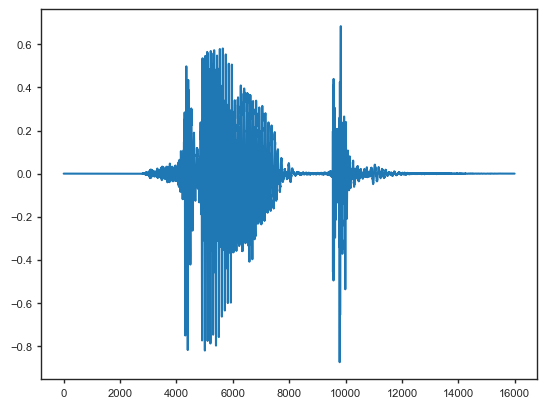

In [3]:
# Create training and testing split of the data. We do not use validation in this tutorial.
val_set = SubsetSC("validation")

waveform, sample_rate, label, speaker_id, utterance_number = val_set[238]
data_config['sample_rate'] = sample_rate

print("Shape of waveform: {}".format(waveform.size()))
print("Sample rate of waveform: {}".format(sample_rate))

plt.plot(waveform.t().numpy());

In [4]:
import IPython.display as ipd
print(label)
ipd.Audio(waveform.numpy(), rate=sample_rate)

right


In [5]:
data_config["n_steps"] = int(data_config["duration"]/dt)
data_config["n_class"] = len(COMMAND20)
n_class = data_config["n_class"]
n_steps = data_config["n_steps"]
answer_steps = int(model_config["answer_period"]/dt)
rootdir = Path('..') / "SpeechCommands" / "Mel_npy"

train_set = ShardedMelDataset(rootdir / 'training')
val_set = ShardedMelDataset(rootdir / 'validation')

mel_sample, label = val_set[0]
print(mel_sample.shape)
data_config['n_mels'] = mel_sample.shape[0]

if device == "cuda":
    num_workers = 0 #train_config['num_workers']
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

if train_config["balance_sampler"]:
    with open(rootdir / "training"/ "label_stats.json") as f:
        label_counts = json.load(f)["label_counts"]
    sampler = make_weighted_sampler(train_set, label_counts)
    shuffle = False
else:
    sampler = None
    shuffle = True

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=128, #train_config['batch_size'],
    shuffle=shuffle,
    sampler=sampler,
    collate_fn=CollateMel(n_steps, n_class, training=True),
    num_workers=1,
    pin_memory=pin_memory,
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=256,
    shuffle=False,
    drop_last=False,
    collate_fn=CollateMel(n_steps, n_class, training=False),
    num_workers=num_workers,
    pin_memory=pin_memory,
)

train_config["batches_per_epoch"] = len(train_loader)

model_config['n_out'] = data_config['n_class']
model_config['n_in'] = data_config['n_mels']

beta = torch.zeros(n_steps).to(device)
beta[-answer_steps:]=1.
beta /= beta.sum()

torch.Size([64, 200])


torch.Size([2, 64, 500]) torch.Size([2, 21])


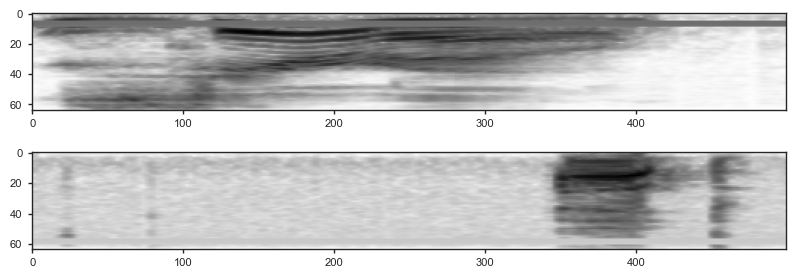

In [6]:
example_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=2,
    shuffle=True,
    collate_fn=CollateMel(n_steps, n_class, training=True, mask_width=0),
    num_workers=1,
    pin_memory=False,
)
mel_sample, label = next(iter(example_loader))
print(mel_sample.shape, label.shape)
del example_loader

fig, axs = plt.subplots(2, 1, figsize=(8, 3))
axs[0].imshow(mel_sample[0].numpy())
axs[1].imshow(mel_sample[1].numpy())
plt.tight_layout()
plt.show()

## Training KP

In [8]:
# init network and optimizer
model = buildKPNet(model_config, general_config).to(device)
model = torch.compile(model)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.4,
    patience=0
)

best_val_acc = 0.

tensor([ 4., 16., 48.,  3., 12., 24.])


In [9]:
print("Training started...")
loss_record = []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    pbar = tqdm(
        enumerate(train_loader, 0),
        total=train_config["batches_per_epoch"],
        disable=not general_config["verbose"],
    )
    for batch_idx, (x, target) in pbar:
        total_error = train_batch_delay(model, optimizer, x.to(device),
                                        target.to(device), answer_steps, beta)
        Cum_errors += total_error

    Cum_errors /= len(train_loader.dataset)

    val_acc, val_loss = test(model, val_loader, answer_steps, beta)
    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {val_loss:.4f},'
        f'Test Acc: {val_acc:.1f},'
        f'Best Acc: {best_val_acc:.1f},'
    )
    pbar.close()

print('finished')

Training started...


  0%|▏                                                                                | 2/663 [00:13<1:15:59,  6.90s/it]


KeyboardInterrupt: 

### Visualize kernel

In [ ]:
kernel_record_post = extract_kernel(
    model,
    n_steps=int(1.5*data_config["final_seq_length"]),
    layer_idx=model_config["num_LP_layers"]
)

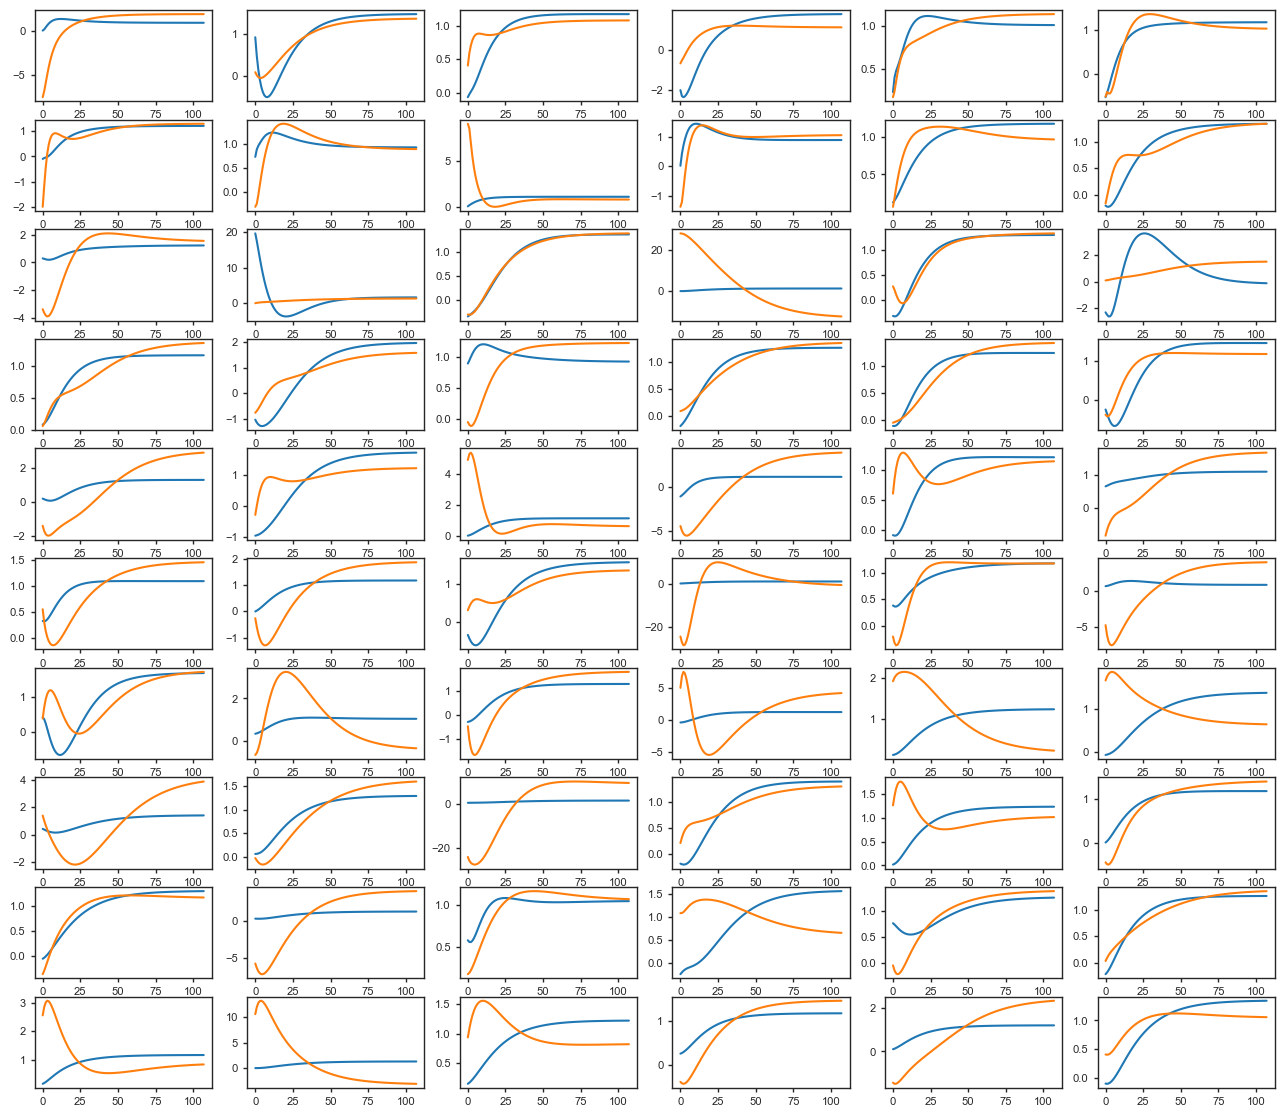

In [ ]:
kernel_record_pre_norm = kernel_record_pre / kernel_record_pre.mean(axis=1)[:, None]
kernel_record_post_norm = kernel_record_post / kernel_record_post.mean(axis=1)[:, None]
fig, axs = plt.subplots(10, 6, figsize=(16, 14))
for i, ax in enumerate(axs.ravel()):
    ax.plot(kernel_record_pre_norm[i])
    ax.plot(kernel_record_post_norm[i])

In [ ]:
# if data_config['preprocessing']=='Mel':
#     transform = torchaudio.transforms.MelSpectrogram(
#         sample_rate=data_config['sample_rate'],
#         n_fft=data_config['n_fft'],
#         win_length=data_config['win_length'],
#         hop_length=data_config['hop_length'],
#         n_mels=data_config['n_mels'],
#         center=True
#     )
# elif data_config['preprocessing']=='Raw':
#     new_sample_rate = 10000
#     transform = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)

# transformed = transform(waveform)[:, :, :-1]

# data_config["final_seq_length"] = transformed.shape[-1]
# data_config["n_class"] = len(LABELS)
# n_class = data_config["n_class"]
# n_steps = data_config["final_seq_length"]
# answer_steps = int(model_config["answer_period"]/dt)

# word_start = "yes"
# index = label_to_index(word_start)
# word_recovered = index_to_label(index)

# print(word_start, "-->", index, "-->", word_recovered,
#       ", transformed shape:", transformed.shape, ", Number of steps:", n_steps)

yes --> tensor(33) --> yes , transformed shape: torch.Size([1, 64, 500]) , Number of steps: 500


## Evaluation

In [7]:
rootdir = Path('..') / "SpeechCommands" / "Mel_npy"
Saved_model = Path("..") / "saved_models" / "Speech90"
with open(Saved_model / "general_config.json") as f:
    general_config = json.load(f)
with open(Saved_model / "model_config.json") as f:
    model_config = json.load(f)
with open(Saved_model / "data_config.json") as f:
    data_config = json.load(f)

dt = general_config["dt"]
n_steps = int(data_config["duration"]/dt)
answer_steps = int(model_config["answer_period"]/dt)

if device == "cuda":
    num_workers = 1
    pin_memory = True
else:
    num_workers = 0
    pin_memory = False

collate_fn = CollateMel(n_steps, data_config['n_class'])

test_set = ShardedMelDataset(rootdir / 'testing')
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=256,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=256,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False,
)

In [8]:
#model = buildKPNet(model_config, general_config).to(device)
model = buildNetCompare(model_config, general_config, neurontype="BPTT").to(device)
model = torch.compile(model)
state_dict = torch.load(Saved_model / "best_model_state.pt", map_location=device, weights_only=True)
print(model.load_state_dict(state_dict))
print(model_config)

beta = torch.zeros(n_steps).to(device)
beta[-answer_steps:]=1.
beta /= beta.sum()

<All keys matched successfully>
{'Ins_size': [400], 'LP_size': [240, 300, 360, 400], 'Tau0': [2, 50, 6], 'Tau1': [3, 12, 24], 'Tau2': [4, 16, 36], 'Tau3': [20, 100.0, 320, 800], 'activation': 'tanh', 'answer_period': 640, 'n_in': 64, 'n_out': 35, 'num_Ins_layers': 1, 'num_LP_layers': 4, 'reducedNonlinear': False, 'rho_scale': 0.6}


In [9]:
model.device = device
for l in model.layers:
    l.device = device

In [10]:
acc, loss, stats = test_analy(model, test_loader, answer_steps, beta, num_classes=data_config['n_class'])

print("Accuracy:", acc)
print("Loss:", loss)
print("Recall per class:", stats["recall"])
print("FN per class:", stats["FN"])

Accuracy: 89.99545661063154
Loss: 0.01515005766830895
Recall per class: tensor([0.9212, 0.8696, 0.8865, 0.9330, 0.8818, 0.8719, 0.9338, 0.8876, 0.8198,
        0.7871, 0.8900, 0.8408, 0.9360, 0.9110, 0.7888, 0.9029, 0.8923, 0.8922,
        0.8642, 0.8955, 0.8662, 0.9073, 0.9040, 0.9507, 0.9528, 0.9645, 0.9659,
        0.8864, 0.8446, 0.9151, 0.8988, 0.9515, 0.8641, 0.9642, 0.8995])
FN per class: tensor([13., 27., 21., 13., 26., 52., 27., 50., 31., 33., 44., 64., 13., 17.,
        34., 40., 21., 44., 55., 42., 53., 37., 38., 20., 10., 14., 14., 46.,
        30., 36., 43.,  8., 28., 15., 42.])


In [11]:
acc, loss, train_stats = test_analy(model, train_loader, answer_steps, beta, num_classes=data_config['n_class'])

print("train set")
print("Accuracy:", acc)
print("Loss:", loss)
print("Recall per class:", train_stats["recall"])
print("FN per class:", train_stats["FN"])

train set
Accuracy: 96.06095965489197
Loss: 0.010113605129462076
Recall per class: tensor([0.9844, 0.9755, 0.9517, 0.9656, 0.9696, 0.9410, 0.9749, 0.9599, 0.9616,
        0.9578, 0.9381, 0.9256, 0.9804, 0.9745, 0.9673, 0.9552, 0.9772, 0.9451,
        0.9466, 0.9455, 0.9488, 0.9627, 0.9656, 0.9688, 0.9782, 0.9773, 0.9775,
        0.9349, 0.9417, 0.9656, 0.9576, 0.9868, 0.9716, 0.9777, 0.9726])
FN per class: tensor([ 21.,  39.,  82.,  57.,  52., 185.,  76., 130.,  49.,  53., 183., 231.,
         32.,  44.,  42., 136.,  39., 174., 167., 162., 158., 117., 104., 100.,
         35.,  70.,  70., 193.,  82., 107., 125.,  17.,  49.,  72.,  89.])


In [12]:
stats

{'TP': tensor([152., 180., 164., 181., 194., 354., 381., 395., 141., 122., 356., 338.,
         190., 174., 127., 372., 174., 364., 350., 360., 343., 362., 358., 386.,
         202., 380., 397., 359., 163., 388., 382., 157., 178., 404., 376.]),
 'FP': tensor([43., 34., 27., 48., 29., 37., 20., 24., 33., 34., 40., 64., 25.,  9.,
         32., 29., 23., 16., 66., 42., 30., 41., 26., 27., 33., 15., 32., 34.,
         27., 27., 42., 34., 24., 17., 17.]),
 'FN': tensor([13., 27., 21., 13., 26., 52., 27., 50., 31., 33., 44., 64., 13., 17.,
         34., 40., 21., 44., 55., 42., 53., 37., 38., 20., 10., 14., 14., 46.,
         30., 36., 43.,  8., 28., 15., 42.]),
 'recall': tensor([0.9212, 0.8696, 0.8865, 0.9330, 0.8818, 0.8719, 0.9338, 0.8876, 0.8198,
         0.7871, 0.8900, 0.8408, 0.9360, 0.9110, 0.7888, 0.9029, 0.8923, 0.8922,
         0.8642, 0.8955, 0.8662, 0.9073, 0.9040, 0.9507, 0.9528, 0.9645, 0.9659,
         0.8864, 0.8446, 0.9151, 0.8988, 0.9515, 0.8641, 0.9642, 0.8995]),
 'preci

In [13]:
index_to_label(13)

'house'

In [ ]:
for i, (waveform, sample_rate, utterance, *_) in enumerate(test_set):
    output = predict(waveform)
    if output != utterance:
        ipd.Audio(waveform.numpy(), rate=sample_rate)
        print(f"Data point #{i}. Expected: {utterance}. Predicted: {output}.")
        break
else:
    print("All examples in this dataset were correctly classified!")
    print("In this case, let's just look at the last data point")
    ipd.Audio(waveform.numpy(), rate=sample_rate)
    print(f"Data point #{i}. Expected: {utterance}. Predicted: {output}.")

## Train BPTT

In [8]:
Method = 'BPTT'
train_fn = train_batch_BPTT

model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)
model = torch.compile(model)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    weight_decay=0.
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=0
)

best_val_acc = 0.

In [9]:
num_epochs = 100
error_record = []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    pbar = tqdm(
        enumerate(train_loader, 0),
        total=train_config["batches_per_epoch"],
        disable=not general_config["verbose"],
    )
    for batch_idx, (x, target) in pbar:
        total_error = train_fn(model, optimizer, x.to(device),
                                        target.to(device), answer_steps, beta)
        Cum_errors += total_error

    Cum_errors /= len(train_loader.dataset)
    val_acc, val_loss = test(model, val_loader, answer_steps, beta)
    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {val_loss:.4f},'
        f'Test Acc: {val_acc:.1f},'
        f'Best Acc: {best_val_acc:.1f},'
    )
    pbar.close()

print('finished')

  5%|████                                                                             | 33/663 [00:31<10:10,  1.03it/s]


KeyboardInterrupt: 

## Check GLE

In [7]:
Method = 'GLE'
model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-3,#train_config["learning_rate"],
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

train_fn = train_batch_delay

best_val_acc = 0.

In [8]:
print("Training started...")
loss_record = []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    pbar = tqdm(
        enumerate(train_loader, 0),
        total=train_config["batches_per_epoch"],
        disable=not general_config["verbose"],
    )
    for batch_idx, (x, target) in pbar:
        total_error = train_batch_delay(model, optimizer, x.to(device),
                                        target.to(device), answer_steps, beta)
        Cum_errors += total_error

    Cum_errors /= len(train_loader.dataset)

    val_acc, val_loss = test(model, val_loader, answer_steps, beta)
    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {val_loss:.4f},'
        f'Test Acc: {val_acc:.1f},'
        f'Best Acc: {best_val_acc:.1f},'
    )
    pbar.close()

print('finished')

Training started...


  2%|█▌                                                                           | 13/663 [00:12<10:06,  1.07it/s]


KeyboardInterrupt: 